<a href="https://colab.research.google.com/github/jarizmendi18-source/repositorio-gestion/blob/main/Copia_de_S05_Gestion3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers datasets evaluate accelerate torch torchvision

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_dataset

DATASET_PATH = "/content/drive/MyDrive/DATOS"

dataset = load_dataset(
    "imagefolder",
    data_dir="/content/drive/MyDrive/Datos2"
)

dataset

Resolving data files:   0%|          | 0/1199 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/300 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1199
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 300
    })
})

In [ ]:
labels = dataset["train"].features["label"].names

print(labels)

id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

print(id2label)

['PANTALON', 'PLAYERA', 'SUDADERA']
{0: 'PANTALON', 1: 'PLAYERA', 2: 'SUDADERA'}


In [ ]:
from transformers import AutoImageProcessor
from transformers import AutoModelForImageClassification

model_name = "google/vit-base-patch16-224"

processor = AutoImageProcessor.from_pretrained(model_name)

model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    ignore_mismatched_sizes=True
)

model.config.id2label = id2label
model.config.label2id = label2id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
def preprocess(example):

    image = example["image"].convert("RGB")

    processed = processor(
        image,
        return_tensors="pt"
    )

    example["pixel_values"] = processed["pixel_values"][0]

    return example

In [ ]:
dataset = dataset.map(preprocess)

Map:   0%|          | 0/1199 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
dataset = dataset.remove_columns(["image"])

In [ ]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    return {

        "accuracy":
        accuracy_metric.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "precision":
        precision_metric.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["precision"],

        "recall":
        recall_metric.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["recall"],

        "f1":
        f1_metric.compute(
            predictions=predictions,
            references=labels,
            average="weighted"
        )["f1"]
    }

In [ ]:
import torch
import numpy as np

def collate_fn(batch):

    pixel_values = torch.tensor(
        np.array(
            [item["pixel_values"] for item in batch]
        ),
        dtype=torch.float32
    )

    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.long
    )

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=10,

    remove_unused_columns=False,

    load_best_model_at_end=True
)

In [ ]:
evaluation_strategy="epoch"

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.126483,0.183706,0.930000,0.937837,0.930000,0.929491
2,0.000614,0.066159,0.983333,0.983879,0.983333,0.983259
3,0.000524,0.072009,0.983333,0.983879,0.983333,0.983259


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=450, training_loss=0.06329719948220171, metrics={'train_runtime': 7815.5119, 'train_samples_per_second': 0.46, 'train_steps_per_second': 0.058, 'total_flos': 2.7874118489037005e+17, 'train_loss': 0.06329719948220171, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000524,0.071595,3,0.983333,0.983879,0.983333,0.983259


{'eval_loss': 0.07159458100795746,
 'eval_accuracy': 0.9833333333333333,
 'eval_precision': 0.9838791571464841,
 'eval_recall': 0.9833333333333333,
 'eval_f1': 0.98325866894787}

In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/modelo_prendas_vit"
)

processor.save_pretrained(
    "/content/drive/MyDrive/modelo_prendas_vit"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/modelo_prendas_vit/preprocessor_config.json']

In [ ]:
from PIL import Image
import torch

ruta = "/content/drive/MyDrive/S05 PRUEBA/1.jpg"

image = Image.open(ruta).convert("RGB")

inputs = processor(
    images=image,
    return_tensors="pt"
)

model.eval()

with torch.no_grad():
    outputs = model(**inputs)

probs = torch.nn.functional.softmax(
    outputs.logits,
    dim=1
)

pred = probs.argmax().item()

print(
    "Clase:",
    model.config.id2label[pred]
)

print(
    "Probabilidad:",
    float(probs[0][pred])
)

Clase: PANTALON
Probabilidad: 0.9999198913574219


In [ ]:
for i, prob in enumerate(probs[0]):

    print(
        model.config.id2label[i],
        round(float(prob)*100,2),
        "%"
    )

PANTALON 99.99 %
PLAYERA 0.0 %
SUDADERA 0.0 %


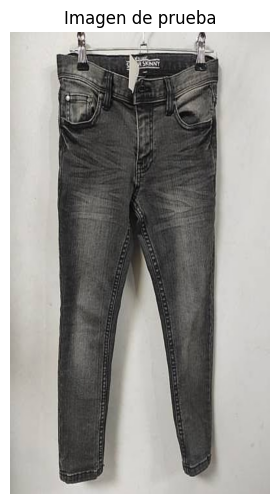

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

ruta = "/content/drive/MyDrive/S05 PRUEBA/1.jpg"

image = Image.open(ruta).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Imagen de prueba")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

predictions = trainer.predict(dataset["test"])

y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(axis=1)

In [ ]:
import pandas as pd

metricas = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Valor": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted"),
        recall_score(y_true, y_pred, average="weighted"),
        f1_score(y_true, y_pred, average="weighted")
    ]
})

print(metricas)

     Métrica     Valor
0   Accuracy  0.983333
1  Precision  0.983879
2     Recall  0.983333
3   F1-Score  0.983259


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=labels
    )
)

              precision    recall  f1-score   support

    PANTALON       0.99      1.00      1.00       100
     PLAYERA       1.00      0.95      0.97       100
    SUDADERA       0.96      1.00      0.98       100

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[100   0   0]
 [  1  95   4]
 [  0   0 100]]


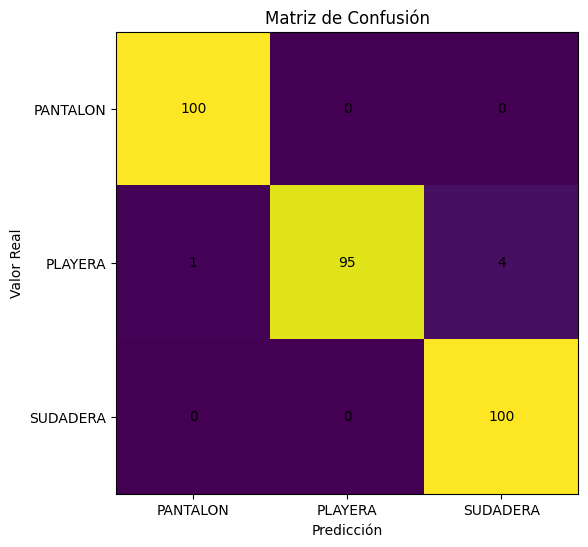

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(cm)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()